## Week 12 and 13 Assignment - DATASCI200 Introduction to Data Science Programming, UC Berkeley MIDS

Write code in this Jupyter Notebook to solve the following problems. Please upload this **Notebook** with your solutions to your GitHub repository and provide a link in the last question in gradescope. 

Assignment due date: 11:59PM PT the night before the Week 13 Live Session. Do **NOT** push/upload the data fil

## Objectives

* Analyze and glean insights from a real dataset using pandas
* Apply pandas for exploratory analysis, information gathering, and discovery
* Practice using matplotlib for data visualization

## General Guidelines:

- This is a **real** dataset but has been cleaned and filtered for this assignment
- This dataset is ~116mb, which will take some time to load (and probably won't load in Google Sheets or Excel)
- If you make assumptions, annotate them in your responses
- While there is one code/markdown cell positioned after each question as a placeholder, some of your code/responses may require multiple cells
- Double-click the markdown cells that say for example **1a answer here:** to enter your written answers. If you need more cells for your written answers, make them markdown cells (rather than code cells)
- This homework assignment is not autograded because of the variety of responses one could give. 
  - Please upload this notebook to the autograder page and the TAs will manually grade it. 
  - Ensure that each cell is run and outputs your answer for ease of grading! 
  - Highly suggest to do a `restart & run all` before uploading your code to ensure everything runs and outputs correctly.
  - Answers without code (or code that runs) will be given 0 points.
- **This is meant to simulate real world data so you will have to do some external research to determine what some of the answers are!** 
- Only use the plotting libraries matplotlib or seaborn for the visualizations.

## Dataset

You are to analyze campaign contributions to the 2016 U.S. presidential primary races made in California. Use the csv file located here: https://drive.google.com/file/d/1ftdw7L9Z6WQJ6i0SXj030PA7ObsXfPsg/view?usp=sharing. You should download and save this file in a folder outside where this notebook is stored. This file originally came from the U.S. Federal Election Commission (https://www.fec.gov/).

This file is already cleaned and ready to use - you **do not** need to filter or clean it anymore! (you may not agree with the how it was cleaned but please use this file as is).

**DO NOT PUSH THIS FILE TO YOUR GITHUB REPO!**

- Best practice is to not have DATA files in your code repo. As shown below, the default load is outside of the folder this notebook is in. If you change the folder where the file is stored please update the first cell!
- If you do accidentally push the file to your github repo - follow the directions here to fix it: https://docs.google.com/document/d/15Irgb5V5G7pKPWgAerH7FPMpKeQRunbNflaW-hR2hTA/edit?usp=sharing

Documentation for this data can be found here: https://drive.google.com/file/d/11o_SByceenv0NgNMstM-dxC1jL7I9fHL/view?usp=sharing

## Setup

Run the cell below as it will load the data into a pandas dataframe named `contrib`. Note that a custom date parser is defined to speed up loading. If Python were to guess the date format, it would take even longer to load.

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# These commands below set some options for pandas and to have matplotlib show the charts in the notebook
pd.set_option('display.max_rows', 1000)
pd.options.display.float_format = '{:,.2f}'.format
%matplotlib inline

# Load the data
# We have this defaulted to the folder OUTSIDE of your repo - please change it as needed
contrib = pd.read_csv('/Users/lacey/github/mids-datasci200-summer2026-lacey-payne/2016_ca_primary_cleaned.csv', index_col=False, parse_dates=['contb_receipt_dt'])

# Note - for now, it is okay to ignore the warning about mixed types.

## 1. Plotting Data (30 points)

Your boss asked for you to make a few charts from the dataset to better explore the information. 

**1a.** Plotting a histogram of contribute amount (10 points)

Make a histogram of the **full range** of values in the `contb_receipt_amt` variable. 

Remember to include on your histogram:
- Include a title
- Include axis labels
- The correct number of bins to see the breakout of values

Based on the histogram - what range of contributions have the highest count frequency?

In [ ]:
# 1a YOUR CODE HERE
df = contrib.groupby('contb_receipt_amt').size().reset_index(name='count') 
print(contrib['contb_receipt_amt'].describe())
plt.figure(figsize=(10, 6))
plt.hist(contrib['contb_receipt_amt'], bins=100, color ='#C0C0F2')
plt.title("Distribution of Campaign Contribution Amounts")
plt.xlabel("Contribution Amount ($)")
plt.ylabel("Frequency")
plt.show()

- **1a answer here:** 
Based on the histogram, it appears that contributions below and near zero had the highest count frequency.

**1b.** Plotting a histogram of contribute amount (10 points)

Make a 'zoomed-in' histogram of the range that had the highest count frequencies from 1a above. 

Remember to include on your histogram:
- Include a title
- Include axis labels
- The correct number of bins to see the breakout of values

What are some insights that you can see from these two histograms (1a and 1b)?

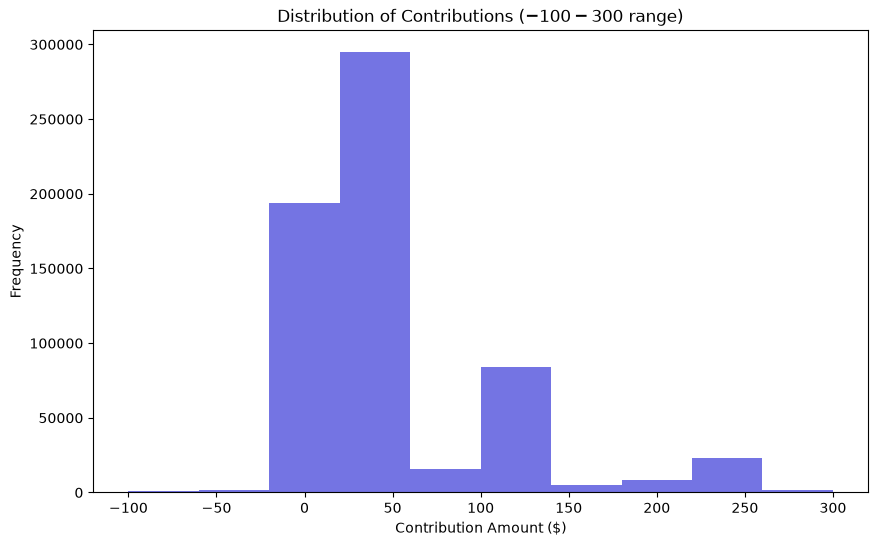

In [3]:
# 1b YOUR CODE HERE
# Adjust range to zoom in based on data obtained from 1a, and adjust as needed to get a good view of the distribution
zoomed = contrib[(contrib['contb_receipt_amt'] >= -100) & (contrib['contb_receipt_amt'] <= 300)]  

plt.figure(figsize=(10, 6))
plt.hist(zoomed['contb_receipt_amt'], bins=10, color ='#7474E3')  # adjust bins based on data obtained in 1a
plt.title("Distribution of Contributions ($-100 - $300 range)")
plt.xlabel("Contribution Amount ($)")
plt.ylabel("Frequency")
plt.show()

- **1b answer here:** 
The contribution amount from > 0 to approximately $50 had the highest frequency. There was a spike between $100 and $150 (~$125?), and a slightly lower spoke around $250. 

**1c.** Present a time-series line chart with the following elements (10 points)  

- The chart needs to have two lines - one for Bernie Sanders and one for Hillary Clinton.
- Show the date on the x-axis
- Add vertical lines for these dates of the primary debates: 17 Jan 2016, 11 Feb 2016, 9 Mar 2016
- Show the total contribution amount for that day on the y-axis
- Include a title
- Include axis labels

How did the debates effect fundraising / donations? Did fundraising increase or decrease after the debates for each candidate?

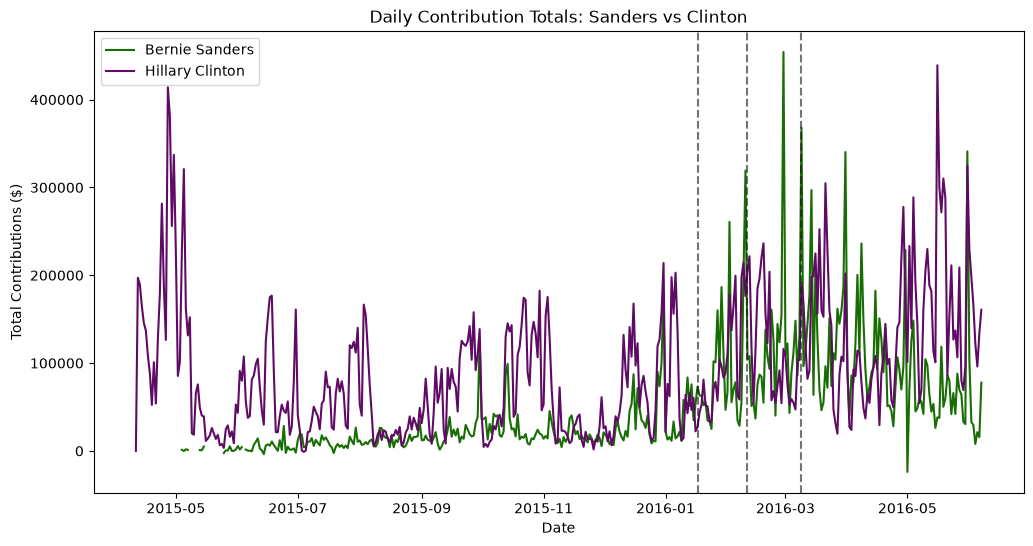

In [4]:
# 1c YOUR CODE HERE
daily = contrib.groupby(['contb_receipt_dt', 'cand_nm'])['contb_receipt_amt'].sum().reset_index()

# Pivot so each candidate gets their own line & the x-axis is the date
daily_pivot = daily.pivot(index='contb_receipt_dt', columns='cand_nm', values='contb_receipt_amt')

plt.figure(figsize=(12, 6))
plt.plot(daily_pivot.index, daily_pivot['Sanders, Bernard'], label='Bernie Sanders', color='#186D03')
plt.plot(daily_pivot.index, daily_pivot['Clinton, Hillary Rodham'], label='Hillary Clinton', color='#5F0B65')

# Add vertical lines for the debate dates
for debate_date in ['2016-01-17', '2016-02-11', '2016-03-09']:
    plt.axvline(pd.to_datetime(debate_date), color='#171717', linestyle='--', alpha=0.6)

# Actually create the plot
plt.title("Daily Contribution Totals: Sanders vs Clinton")
plt.xlabel("Date")
plt.ylabel("Total Contributions ($)")
plt.legend()
plt.show()

- **1c answer here:** 
It appears Bernie Sanders' contributions increased with each debate; slightly at the first debate and more significantly after the next two. Hillary Clinton's daily contributions decreased after the first two debates and rose at the third debate. Based on this information, it appears that debates have more of a positive than negative effect on fundraising. Out of the 6 debate dates (three for each candidate), 4 showed an increase in funding, so that would be 67% positive, 33% negative. However, this is a very small sample and additional data should be reviewed if relying on this information for decision-making purposes.

## 2. Exploring Campaign Contributions (35 points)

Let's investigate the donations to the candidates. (5 points)

**2a.** Present a table that shows the number of donations to each candidate sorted by number of donations.**

- When presenting data as a table, it is often best to sort the data in a meaningful way. This makes it easier for your reader to examine what you've done and to glean insights.  From now on, all tables that you present in this assignment (and course) should be sorted.
- Hint: Use the `groupby` method. Groupby is explained in Unit 13: async 13.3 & 13.5
- Hint: Use the `sort_values` method to sort the data so that candidates with the largest number of donations appear on top.

Which candidate received the largest number/count of contributions (variable 'contb_receipt_amt')?

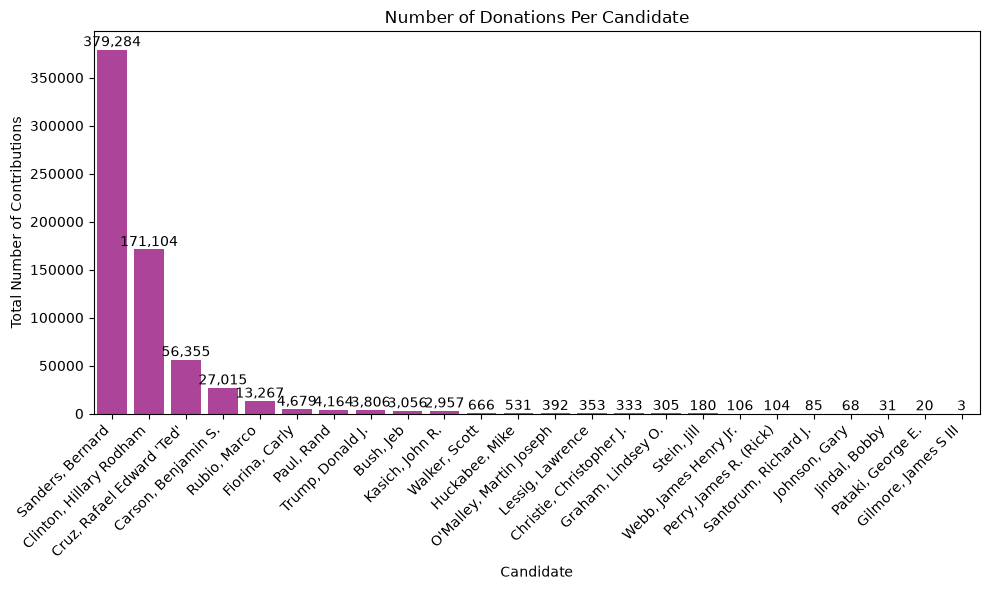

In [5]:
# 2a YOUR CODE HERE
count_by_cand = contrib.groupby('cand_nm').size().reset_index(name='num_donations')
count_by_cand = count_by_cand.sort_values(by='num_donations', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='cand_nm', y='num_donations', color='#BD33A4', data=count_by_cand, ax=ax)
plt.title("Number of Donations Per Candidate")
plt.xlabel("Candidate")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Total Number of Contributions")
ax.bar_label(ax.containers[0], labels=count_by_cand['num_donations'].apply(lambda x: f'{x:,.0f}'), label_type='edge', fontsize=10, color='black')
plt.tight_layout()
plt.show()

- **2a answer here:** 
Bernie Sanders received the largest number of donations to his campaign.

**2b.** Now, present a table that shows the total value of donations to each candidate sorted by total value of the donations. (5 points)

Which candidate raised the most money in California?

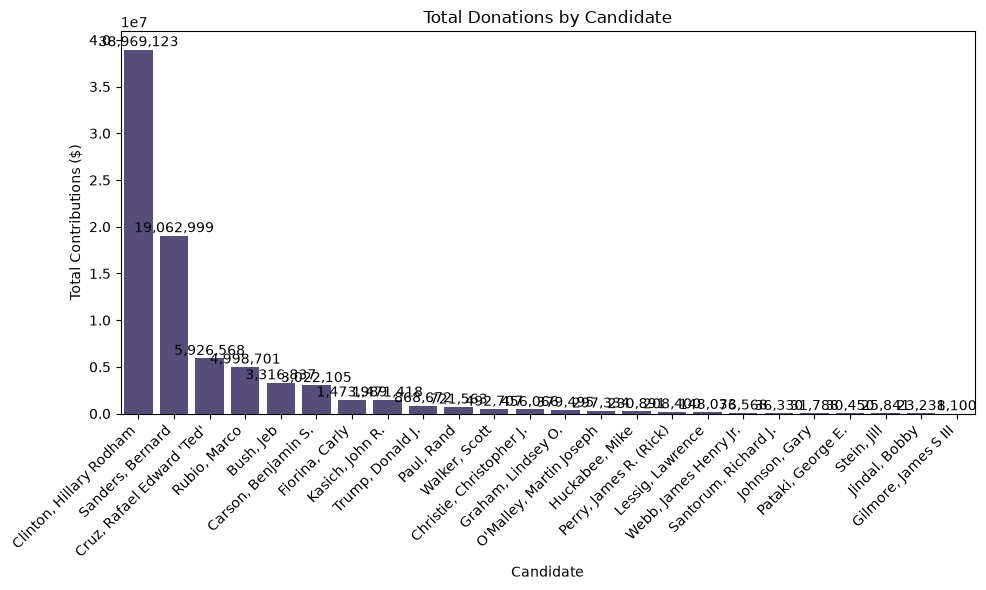

In [6]:
# 2b YOUR CODE HERE
money_by_cand = contrib.groupby('cand_nm')['contb_receipt_amt'].sum().reset_index()
money_by_cand = money_by_cand.rename(columns={'contb_receipt_amt': 'total_donation_amount'})
money_by_cand = money_by_cand.sort_values(by='total_donation_amount', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='cand_nm', y='total_donation_amount', color='#534582', data=money_by_cand, ax=ax)
plt.title("Total Donations by Candidate")
plt.xlabel("Candidate")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Total Contributions ($)")
ax.bar_label(ax.containers[0], labels=money_by_cand['total_donation_amount'].apply(lambda x: f'{x:,.0f}'), label_type='edge', fontsize=10, color='black')
plt.tight_layout()
plt.show()

- **2b answer here:** 
Hillary Rodham Clinton had the largest amount of money donated to her campaign.

**2c.** Combine the tables (sorted by either a or b above). (5 points)

- Looking at the two tables you presented above - if those tables are Series convert them to DataFrames.
- Rename the variable (column) names to accurately describe what is presented.
- Merge together your tables to show the *count* and the *value* of donations to each candidate in one table.
- Hint: Use the `merge` method.

In [7]:
# 2c YOUR CODE HERE
combined = pd.merge(count_by_cand, money_by_cand, on='cand_nm')
combined = combined.sort_values(by='total_donation_amount', ascending=False) 
combined

,cand_nm,num_donations,total_donation_amount
1,"Clinton, Hillary Rodham",171104,"38,969,122.68"
0,"Sanders, Bernard",379284,"19,062,998.80"
2,"Cruz, Rafael Edward 'Ted'",56355,"5,926,568.27"
4,"Rubio, Marco",13267,"4,998,700.92"
8,"Bush, Jeb",3056,"3,316,836.83"
3,"Carson, Benjamin S.",27015,"3,022,105.15"
5,"Fiorina, Carly",4679,"1,473,989.42"
9,"Kasich, John R.",2957,"1,471,417.54"
7,"Trump, Donald J.",3806,"868,672.16"
6,"Paul, Rand",4164,"721,563.14"


**2d. Calculate and add a new variable to the table from 2c that shows the average \$ per donation. Print this table sorted by the average donation** (5 points)

Which candidate had the highest average donation?

In [8]:
# 2d YOUR CODE HERE
combined['average_donation'] = combined['total_donation_amount'] / combined['num_donations']
combined = combined.sort_values(by='average_donation', ascending=False)
combined

,cand_nm,num_donations,total_donation_amount,average_donation
23,"Gilmore, James S III",3,"8,100.00","2,700.00"
18,"Perry, James R. (Rick)",104,"208,400.00","2,003.85"
22,"Pataki, George E.",20,"30,450.00","1,522.50"
14,"Christie, Christopher J.",333,"456,066.00","1,369.57"
15,"Graham, Lindsey O.",305,"379,495.00","1,244.25"
8,"Bush, Jeb",3056,"3,316,836.83","1,085.35"
12,"O'Malley, Martin Joseph",392,"297,334.26",758.51
21,"Jindal, Bobby",31,"23,231.26",749.40
10,"Walker, Scott",666,"492,706.90",739.80
17,"Webb, James Henry Jr.",106,"76,568.16",722.34


- **2d answer here:** 
James S Gilmore III had the highest average donation, at $2,700.00. However, he had only 3 total donations, so if one of those were unusually large it could easily elevate the average. The next highest was James R. (Rick) Perry; he had 104 donors and an average donation of $2,003.85; his information may be a more reliable benchmark as with a higher number of donors, it would be unlikely for a single donation to have an overly large influence on the average.

**2e. Plotting a Bar Chart** (10 points)

Make a single bar chart that shows two different bars per candidate with one bar as the total value of the donations and the other as average $ per donation. 
- Show the Candidates Name on the x-axis
- Show the amount on the y-axis
- Include a title
- Include axis labels
- Sort by total value of the donations
- Make the y-axis a log-scale to show both numbers! (matplotlib docs: https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.yscale.html )

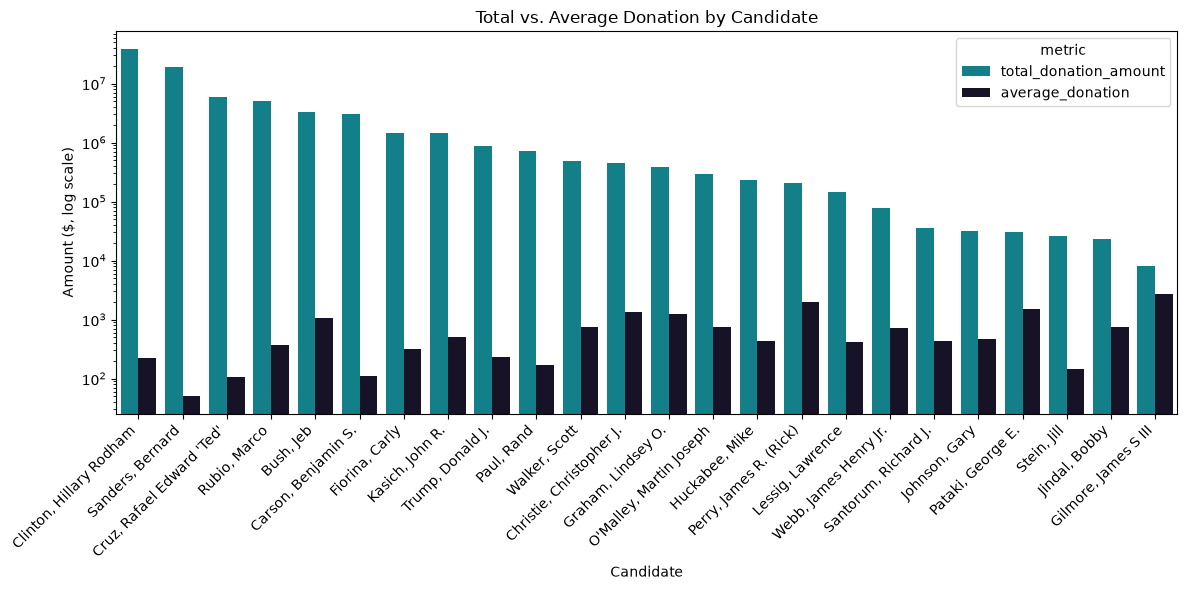

In [9]:
# 2e YOUR CODE HERE
combined = combined.sort_values(by='total_donation_amount', ascending=False)

melted = combined.melt(id_vars='cand_nm', value_vars=['total_donation_amount', 'average_donation'], 
                       var_name='metric', value_name='amount')

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x='cand_nm', y='amount', hue='metric', data=melted, ax=ax, palette=['#008F9B', '#160F29'])
plt.yscale('log')
plt.title("Total vs. Average Donation by Candidate")
plt.xlabel("Candidate")
plt.ylabel("Amount ($, log scale)")
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**2f. Comment on the results of your data analysis in a short paragraph.** (5 points)

- There are several interesting conclusions you can draw from the table you have created.
- What have you learned about campaign contributions in California?
- We are looking for data insights here rather than comments on the code!

- **2f answer here:** 
Two of the more popular Democratic candidates received both the highest number of donations and highest number of donations, respectively. This reinforces that California is a blue state. The larger differences between total donation amount and average donation for certain candidates (most prominently Bernie Sanders; the other more obvious differenes were Ted Cruz, Ben Carson, and Jill Stein) show that these candidates likely received more donations from individuals vs. corporations and PACs. The only candidates with an average donation in the 4 figures were all Republican; this makes it appear that fewer individuals agree with their political stances, but the ones who do are willing to donate more. It was also interesting that of the candidates with average donation amounts over $1,000 were unpopular/lacking in widespread name recognition for the most part; my conjecture is that while these candidates were unlikely to make it through the primary and become the party's candidate, the individuals who donated agreed strongly with their viewpoints and (again, conjecture) hoped their larger donations would help their preferred candidate get farther in the election process and possibly become the party's candidate. 

## 3. Exploring Donor Occupations (35 points)

Above in part 2, we saw that some simple data analysis can give us insights into the campaigns of our candidates. Now let's quickly look to see what *kind* of person is donating to each campaign using the `contbr_occupation` variable.

**3a.** Show the top 5 occupations of individuals that contributed to Hillary Clinton. (5 points)

- Subset your data to create a dataframe with only donations for Hillary Clinton.
- Then use the `value_counts` and `head` methods to present the top 5 occupations (`contbr_occupation`) for her donors.
- Note: we are just interested in the count of donations, not the value of those donations.

In [10]:
# 3a YOUR CODE HERE
clinton_donors = contrib[contrib['cand_nm'] == 'Clinton, Hillary Rodham'] 

top_occupations = clinton_donors['contbr_occupation'].value_counts().head(5)
top_occupations


contbr_occupation
RETIRED                  35767
ATTORNEY                  7514
INFORMATION REQUESTED     4991
TEACHER                   3848
HOMEMAKER                 3522
Name: count, dtype: int64

**3b.** Write a function called `get_donors`. (5 points)
 
Imagine that you want to do the previous operation on several candidates.  To keep your work neat, you want to take the work you did on the Clinton-subset and wrap it in a function that you can apply to other subsets of the data.

- The function should take a DataFrame as a parameter, and return a Series containing the counts for the top 5 occupations contained in that DataFrame.

In [11]:
def get_donors(df):
    """This function takes a dataframe that contains a variable named contbr_occupation.
    It outputs a Series containing the counts for the 5 most common values of that
    variable."""
    
    # 3b YOUR CODE HERE
def get_donors(df):
    top_occupations = df['contbr_occupation'].value_counts().head(5)
    return top_occupations

**3c.** Now run the `get_donors` function from 3b on subsets of the dataframe corresponding to three candidates. Show each of the three candidates below. (5 points)

- Hillary Clinton
- Bernie Sanders
- Donald Trump

In [12]:
# 3c YOUR CODE HERE
bernie_donors = contrib[contrib['cand_nm'] == 'Sanders, Bernard']
trump_donors = contrib[contrib['cand_nm'] == 'Trump, Donald J.'] 

print(get_donors(clinton_donors))
print(get_donors(bernie_donors))
print(get_donors(trump_donors))

contbr_occupation
RETIRED                  35767
ATTORNEY                  7514
INFORMATION REQUESTED     4991
TEACHER                   3848
HOMEMAKER                 3522
Name: count, dtype: int64
contbr_occupation
NOT EMPLOYED         98217
RETIRED              15352
TEACHER              10390
SOFTWARE ENGINEER     7957
ENGINEER              7237
Name: count, dtype: int64
contbr_occupation
RETIRED                  1719
INFORMATION REQUESTED      88
CEO                        62
SALES                      58
OWNER                      57
Name: count, dtype: int64


**3d.** Finally, use `groupby` to separate the entire dataset by candidate. (10 points)

- Call .apply(get_donors) on your groupby object, which will apply the function you wrote to each subset of your data.
- Look at your output and marvel at what pandas can do in just one line!

In [13]:
# 3d YOUR CODE HERE
contrib.groupby('cand_nm').apply(get_donors)

cand_nm                    contbr_occupation                     
Bush, Jeb                  RETIRED                                     992
                           HOMEMAKER                                   177
                           ATTORNEY                                     90
                           Q.A.                                         89
                           PRESIDENT                                    83
Carson, Benjamin S.        RETIRED                                   13635
                           INFORMATION REQUESTED PER BEST EFFORTS     1610
                           HOMEMAKER                                  1028
                           PHYSICIAN                                   321
                           R.N.                                        232
Christie, Christopher J.   RETIRED                                      38
                           NONE                                         22
                           CONSULT

**3e.** Comment on your data insights & findings in a short paragraph. (5 points)

- **3e answer here:** 
'Retired' is the top occupation listing for the majority of each candidate's donors. This tells me that Gen X, Millenials, Gen Z, and Gen Alpha (once they're old enough to vote) need to prioritize exercising their right to vote rather than allowing retirees (who are unlikely to know about the current job market and other economic factors the younger generations face) to have such a massive influence on their lives by electing politicians who focus mostly on their own interests, which are commonly opposed to younger voters' views. James S. Gilmore III's 3 donors were in high-paying occupations; they were a Financial Advisor, a COB, and the third worked in Investment Management. This means the earlier concern about one high donor having a large influence on his campaign's average donation amount is unlikely since all three are high-paying occupations. I researched who the democratic, republican, and third-party candidates for the 2016 presidential primary in California and many of the names included in the dataset were not present, which indicates that their campaigns likely halted operations prior to the primary. I discovered several candidates were not included in the dataset and found it interesting that all republican candidates were included while several democratic and third-party candidates were excluded.

**3f.** Think about your findings in section 3 vs. your findings in section 2 of this assignment. (5 points)

Do you have any new data insights into the results you saw in section 2 now that you see the top occupations for each candidate?

- **3f answer here:** 
Yes. Bernie Sanders voters' top occupation was listed as 'unemployed'; this could be a good explanation for why the average donation was so small. It's impressive that he was able to generate such a large amount of total money donated with such a small average donation. Both of the top democratic candidates were in the lowest 6 out of 23 candidates for average campaign contribution amount; this appears to indicate higher popularity among votes since they were the top two in total donations. Interestingly, the top 6 for average campaign contributions were all republican despite the occupations listing 'retired' as a top occupation; this dispells the stereotype of the poor retiree living on a fixed income and shows that retirees still have a high amount of purchasing power and therefore influence. Although it's outside the scope of the assignment, it would be interesting to stratify the voters for each candidate by age and see what correlations could be found. 

## If you have feedback for this homework, please submit it using the link below:

http://goo.gl/forms/74yCiQTf6k